# Credit Card Fraud Detection
### Advanced Machine Learning Approach for Imbalanced Data Classification

**Author:** Mohd Shadab  
**Date:** March 2026  
**Type:** Binary Classification

---

## Table of Contents

1. About the Dataset
2. Import Libraries & Setup
3. Data Loading & Overview
4. Exploratory Data Analysis (EDA)
5. Data Preprocessing
6. Handling Imbalanced Data
7. Feature Engineering & Selection
8. Model Building & Training
9. Model Evaluation & Comparison
10. Conclusion & Key Insights

---

## 1. About the Dataset

The dataset contains transactions made by credit cards in September 2013 by European cardholders. This dataset presents transactions that occurred in two days, where we have **492 frauds** out of **284,807 transactions**. The dataset is highly unbalanced, the positive class (frauds) account for **0.172%** of all transactions.

### Key Features:
- **V1-V28**: Principal components obtained with PCA (confidential data)
- **Time**: Seconds elapsed between each transaction
- **Amount**: Transaction amount
- **Class**: 1 for fraud, 0 for non-fraud

### Key Challenges:
| Metric | Value |
|--------|-------|
| Fraud Rate | 0.172% |
| Imbalance Ratio | 578:1 |
| Total Records | 284,807 |
| Features | 31 |

## 2. Import Libraries & Setup

In [1]:
# Core Libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, 
                             roc_curve, precision_recall_curve, f1_score, 
                             precision_score, recall_score, accuracy_score)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Imbalanced Learning
from imblearn.over_sampling import SMOTE

# Feature Selection
from sklearn.feature_selection import mutual_info_classif

# Set random seed
np.random.seed(42)

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully!")

All libraries imported successfully!


## 3. Data Loading & Overview

In [2]:
# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv')

print(f"Dataset Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Dataset Shape: 284,807 rows x 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Dataset Information
print("Dataset Information")
print("=" * 60)
df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  flo

In [4]:
# Statistical Summary
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
# Check for missing values
missing = df.isnull().sum()
print("Missing Values Analysis")
print("=" * 60)
print(f"Total Missing: {missing.sum()}")
if missing.sum() == 0:
    print("No missing values found!")

Missing Values Analysis
Total Missing: 0
No missing values found!


In [6]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate Records: {duplicates:,} ({(duplicates/len(df))*100:.2f}%)")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"New dataset shape: {df.shape[0]:,} rows")

Duplicate Records: 1,081 (0.38%)
New dataset shape: 283,726 rows


## 4. Exploratory Data Analysis (EDA)

> **Important:** This dataset is highly imbalanced with only 0.172% fraud cases. This presents a significant challenge for machine learning models.

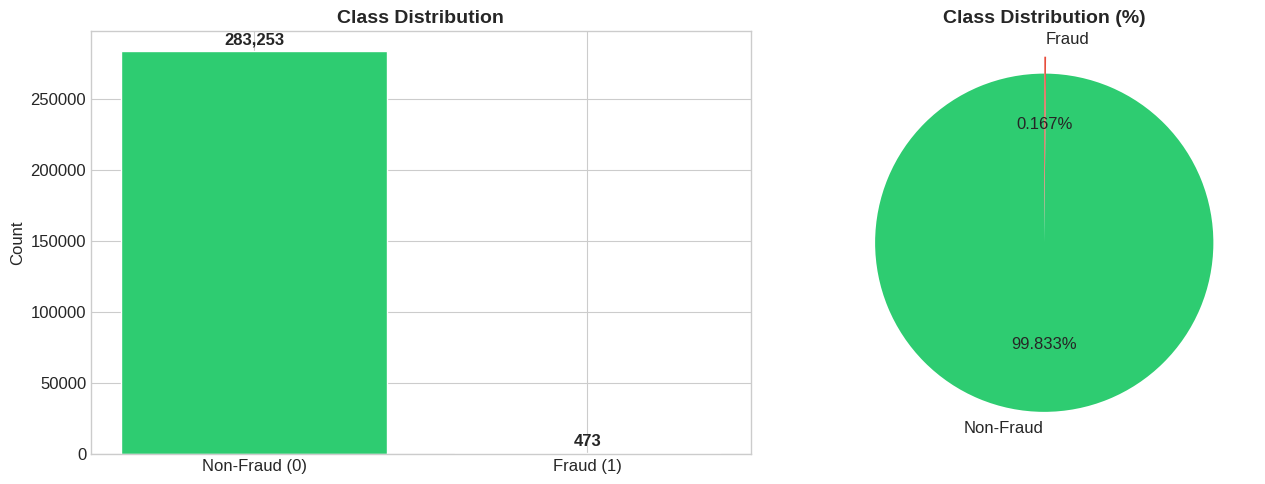

Non-Fraud: 283,253 (99.833%)
Fraud: 473 (0.167%)
Imbalance Ratio: 599:1


In [7]:
# Class Distribution Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
class_counts = df['Class'].value_counts()
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(['Non-Fraud (0)', 'Fraud (1)'], class_counts.values, color=colors, edgecolor='white')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, count in enumerate(class_counts.values):
    axes[0].text(i, count + 5000, f'{count:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=['Non-Fraud', 'Fraud'], autopct='%1.3f%%', 
            colors=colors, explode=(0, 0.1), startangle=90)
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Non-Fraud: {class_counts[0]:,} ({class_counts[0]/len(df)*100:.3f}%)")
print(f"Fraud: {class_counts[1]:,} ({class_counts[1]/len(df)*100:.3f}%)")
print(f"Imbalance Ratio: {class_counts[0]/class_counts[1]:.0f}:1")

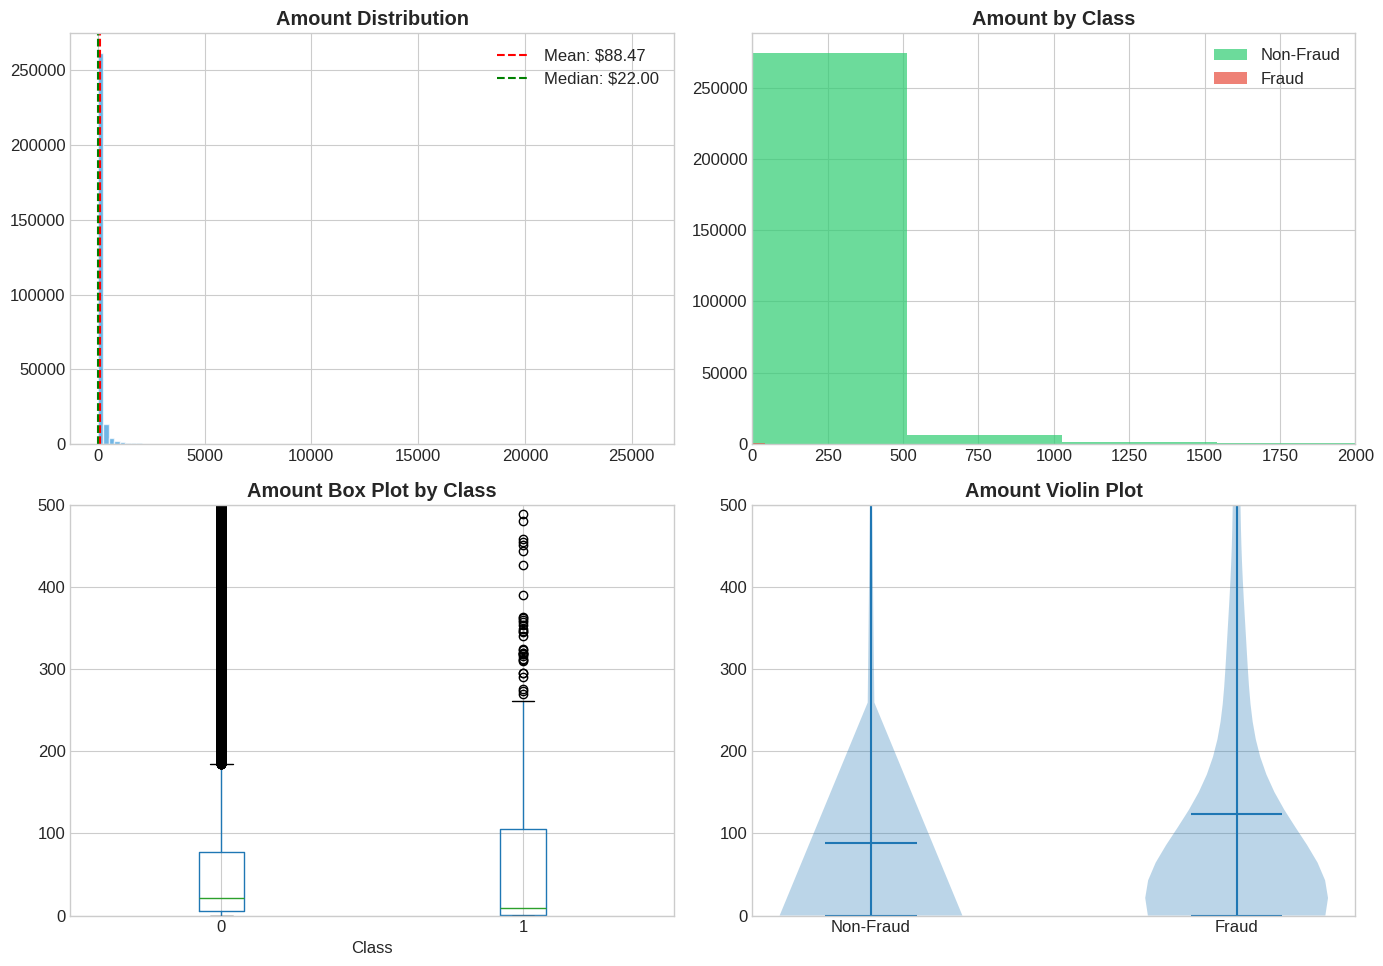

In [8]:
# Transaction Amount Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Amount distribution
axes[0,0].hist(df['Amount'], bins=100, color='#3498db', edgecolor='white', alpha=0.7)
axes[0,0].axvline(df['Amount'].mean(), color='red', linestyle='--', label=f'Mean: ${df["Amount"].mean():.2f}')
axes[0,0].axvline(df['Amount'].median(), color='green', linestyle='--', label=f'Median: ${df["Amount"].median():.2f}')
axes[0,0].set_title('Amount Distribution', fontweight='bold')
axes[0,0].legend()

# Amount by Class
axes[0,1].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.7, label='Non-Fraud', color='#2ecc71')
axes[0,1].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.7, label='Fraud', color='#e74c3c')
axes[0,1].set_title('Amount by Class', fontweight='bold')
axes[0,1].legend()
axes[0,1].set_xlim(0, 2000)

# Box plot
df.boxplot(column='Amount', by='Class', ax=axes[1,0])
axes[1,0].set_title('Amount Box Plot by Class', fontweight='bold')
axes[1,0].set_ylim(0, 500)
plt.suptitle('')

# Violin plot
fraud_amt = df[df['Class']==1]['Amount']
non_fraud_amt = df[df['Class']==0]['Amount']
parts = axes[1,1].violinplot([non_fraud_amt, fraud_amt], positions=[0, 1], showmeans=True)
axes[1,1].set_xticks([0, 1])
axes[1,1].set_xticklabels(['Non-Fraud', 'Fraud'])
axes[1,1].set_title('Amount Violin Plot', fontweight='bold')
axes[1,1].set_ylim(0, 500)

plt.tight_layout()
plt.show()

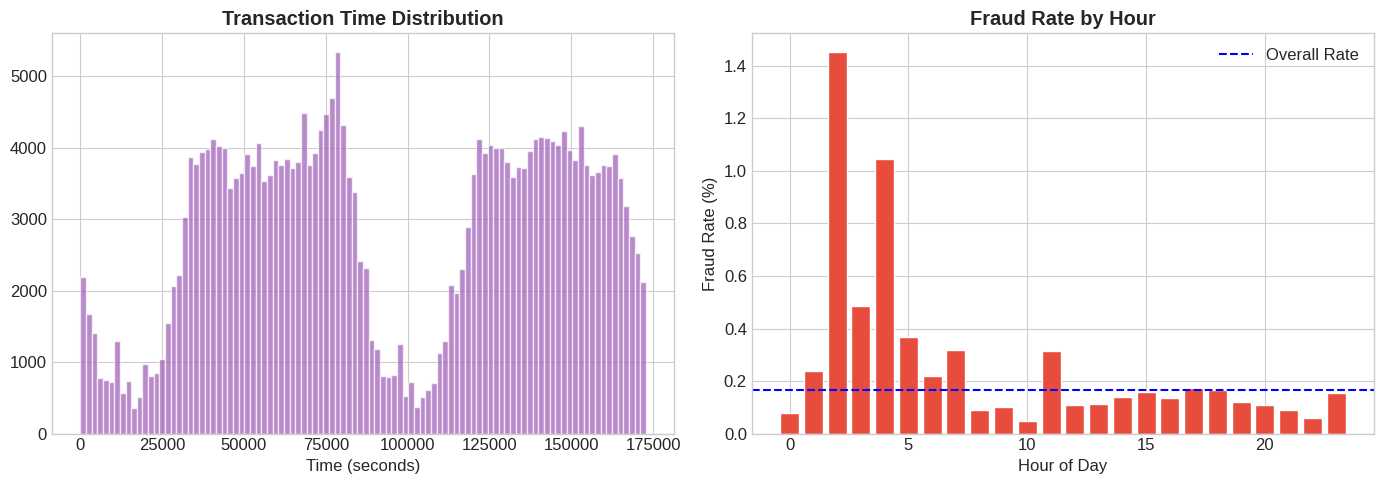

In [9]:
# Time Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time distribution
axes[0].hist(df['Time'], bins=100, color='#9b59b6', edgecolor='white', alpha=0.7)
axes[0].set_title('Transaction Time Distribution', fontweight='bold')
axes[0].set_xlabel('Time (seconds)')

# Hourly fraud rate
df['Hour'] = (df['Time'] // 3600) % 24
fraud_rate = df.groupby('Hour')['Class'].mean() * 100
axes[1].bar(fraud_rate.index, fraud_rate.values, color='#e74c3c', edgecolor='white')
axes[1].axhline(y=df['Class'].mean()*100, color='blue', linestyle='--', label='Overall Rate')
axes[1].set_title('Fraud Rate by Hour', fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

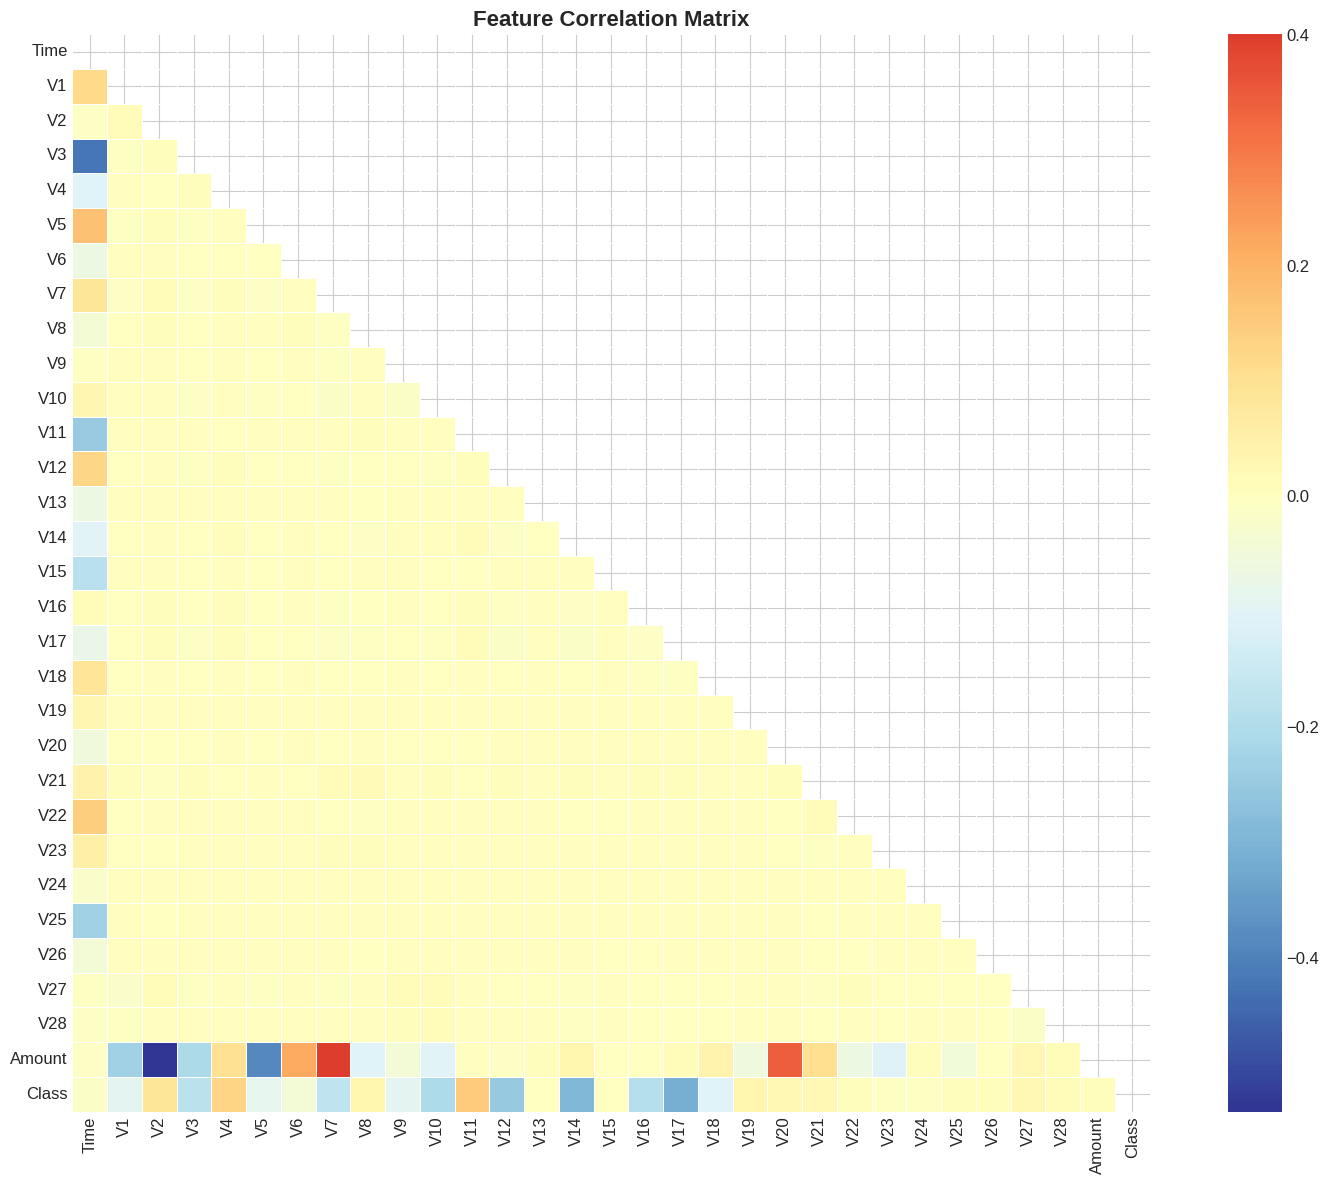

Top 10 Features Correlated with Fraud:
1. V17: 0.3135
2. V14: 0.2934
3. V12: 0.2507
4. V10: 0.2070
5. V16: 0.1872
6. V3: 0.1823
7. V7: 0.1723
8. V11: 0.1491
9. V4: 0.1293
10. V18: 0.1053


In [10]:
# Correlation Analysis
fig, ax = plt.subplots(figsize=(16, 12))

corr = df.drop('Hour', axis=1).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, cmap='RdYlBu_r', center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with Class
print("Top 10 Features Correlated with Fraud:")
print("=" * 40)
top_corr = corr['Class'].drop('Class').abs().sort_values(ascending=False).head(10)
for i, (feat, val) in enumerate(top_corr.items(), 1):
    print(f"{i}. {feat}: {val:.4f}")

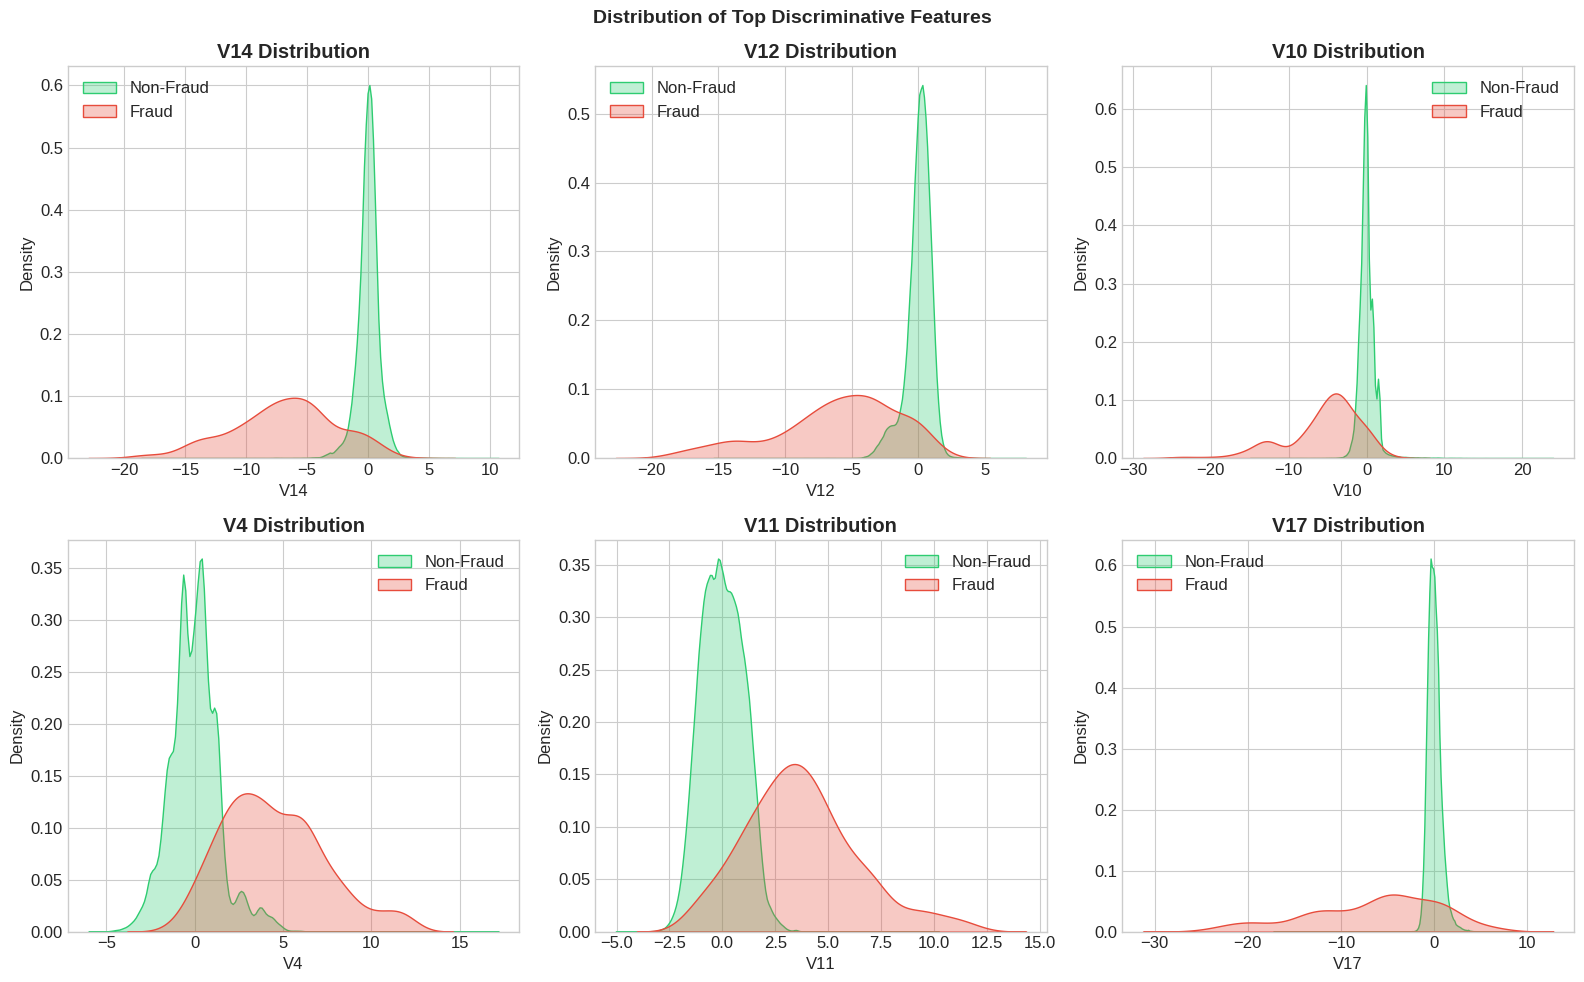

In [11]:
# Distribution of Top Features
top_features = ['V14', 'V12', 'V10', 'V4', 'V11', 'V17']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feat in enumerate(top_features):
    sns.kdeplot(data=df[df['Class']==0], x=feat, ax=axes[idx], label='Non-Fraud', 
                color='#2ecc71', fill=True, alpha=0.3)
    sns.kdeplot(data=df[df['Class']==1], x=feat, ax=axes[idx], label='Fraud', 
                color='#e74c3c', fill=True, alpha=0.3)
    axes[idx].set_title(f'{feat} Distribution', fontweight='bold')
    axes[idx].legend()

plt.suptitle('Distribution of Top Discriminative Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Data Preprocessing

In [12]:
# Prepare data for modeling
print("Data Preprocessing")
print("=" * 60)

# Drop Hour column
if 'Hour' in df.columns:
    df = df.drop('Hour', axis=1)

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

print(f"Features shape: {X.shape}")
print(f"Target distribution: {dict(y.value_counts())}")

Data Preprocessing
Features shape: (283726, 30)
Target distribution: {0: np.int64(283253), 1: np.int64(473)}


In [13]:
# Scale features
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Features scaled using RobustScaler")

Features scaled using RobustScaler


In [14]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set: {X_test.shape[0]:,} samples")
print(f"Training fraud cases: {y_train.sum()}")
print(f"Test fraud cases: {y_test.sum()}")

Training set: 226,980 samples
Test set: 56,746 samples
Training fraud cases: 378
Test fraud cases: 95


## 6. Handling Imbalanced Data

> **Why Handle Imbalanced Data?** Machine learning algorithms trained on imbalanced data tend to be biased towards the majority class. We will use **SMOTE (Synthetic Minority Over-sampling Technique)** to create synthetic samples of the minority class.

In [15]:
# Apply SMOTE
print("Applying SMOTE Oversampling")
print("=" * 60)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original: {X_train.shape[0]:,} samples")
print(f"Resampled: {X_train_res.shape[0]:,} samples")
print(f"New distribution: {dict(y_train_res.value_counts())}")

Applying SMOTE Oversampling
Original: 226,980 samples
Resampled: 453,204 samples
New distribution: {0: np.int64(226602), 1: np.int64(226602)}


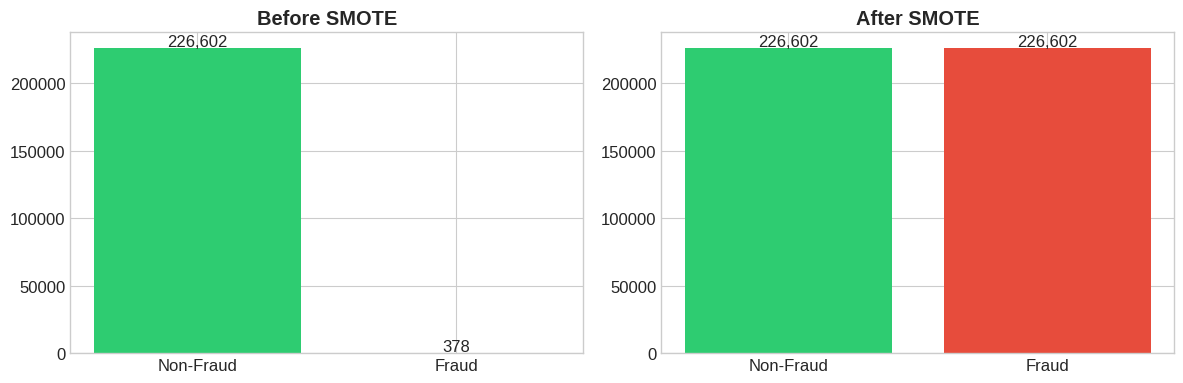

In [16]:
# Visualize SMOTE effect
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before = y_train.value_counts()
after = y_train_res.value_counts()

axes[0].bar(['Non-Fraud', 'Fraud'], before.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Before SMOTE', fontweight='bold')
for i, v in enumerate(before.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center')

axes[1].bar(['Non-Fraud', 'Fraud'], after.values, color=['#2ecc71', '#e74c3c'])
axes[1].set_title('After SMOTE', fontweight='bold')
for i, v in enumerate(after.values):
    axes[1].text(i, v + 1000, f'{v:,}', ha='center')

plt.tight_layout()
plt.show()

## 7. Feature Engineering & Selection

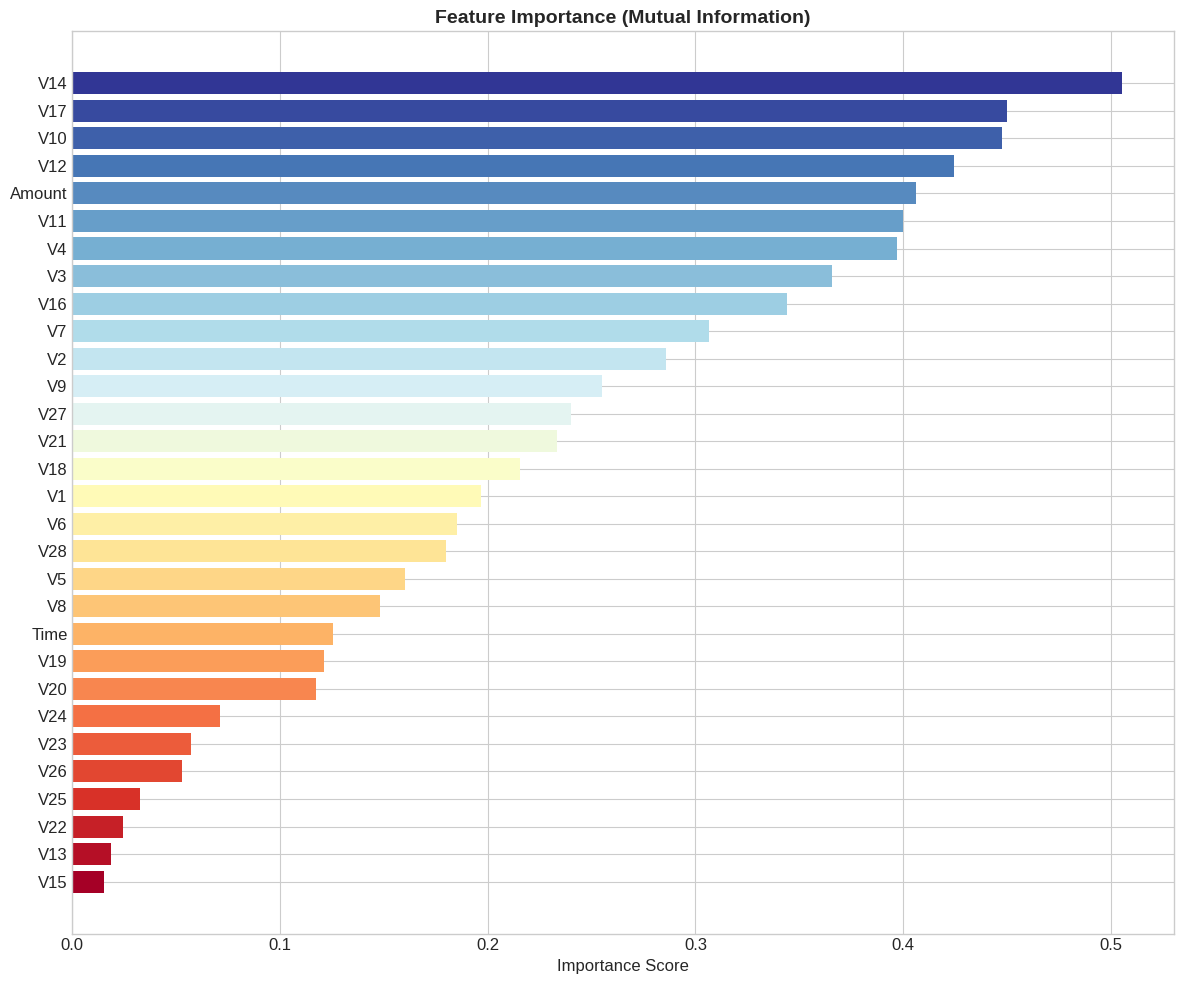

Top 10 Important Features:
Feature  Importance
     V7    0.306481
    V16    0.343914
     V3    0.365879
     V4    0.396828
    V11    0.400136
 Amount    0.406409
    V12    0.424684
    V10    0.447383
    V17    0.450222
    V14    0.505178


In [17]:
# Feature Importance using Mutual Information
mi_scores = mutual_info_classif(X_train_res, y_train_res, random_state=42)
mi_df = pd.DataFrame({'Feature': X.columns, 'Importance': mi_scores})
mi_df = mi_df.sort_values('Importance', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
colors = plt.cm.RdYlBu(np.linspace(0, 1, len(mi_df)))
ax.barh(mi_df['Feature'], mi_df['Importance'], color=colors)
ax.set_title('Feature Importance (Mutual Information)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Top 10 Important Features:")
print(mi_df.tail(10).to_string(index=False))

## 8. Model Building & Training

We will train and compare the following models:
- **Logistic Regression** - Linear baseline
- **Decision Tree** - Interpretable model
- **Random Forest** - Ensemble method
- **XGBoost** - Gradient boosting
- **LightGBM** - Fast gradient boosting

In [18]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, 
                             random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, 
                               random_state=42, verbose=-1)
}

results = {}
trained_models = {}

print("Training Models...")
print("=" * 60)

Training Models...


In [19]:
# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")
    
    model.fit(X_train_res, y_train_res)
    trained_models[name] = model
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'y_pred': y_pred,
        'y_proba': y_proba
    }
    
    print(f"Done! F1: {results[name]['F1']:.4f}, ROC-AUC: {results[name]['ROC-AUC']:.4f}")

print("\n" + "=" * 60)
print("All models trained!")


Training Logistic Regression...
Done! F1: 0.1034, ROC-AUC: 0.9602

Training Decision Tree...
Done! F1: 0.1551, ROC-AUC: 0.8522

Training Random Forest...
Done! F1: 0.7716, ROC-AUC: 0.9817

Training XGBoost...
Done! F1: 0.5200, ROC-AUC: 0.9730

Training LightGBM...
Done! F1: 0.5067, ROC-AUC: 0.9683

All models trained!


## 9. Model Evaluation & Comparison

In [20]:
# Performance comparison table
comparison = pd.DataFrame({
    name: {
        'Accuracy': f"{m['Accuracy']:.4f}",
        'Precision': f"{m['Precision']:.4f}",
        'Recall': f"{m['Recall']:.4f}",
        'F1-Score': f"{m['F1']:.4f}",
        'ROC-AUC': f"{m['ROC-AUC']:.4f}"
    }
    for name, m in results.items()
}).T

print("Model Performance Comparison")
print("=" * 80)
comparison

Model Performance Comparison


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.9746,0.0550,0.8737,0.1034,0.9602
Decision Tree,0.9858,0.0861,0.7789,0.1551,0.8522
Random Forest,0.9992,0.7451,0.8000,0.7716,0.9817
XGBoost,0.9975,0.3805,0.8211,0.5200,0.9730
LightGBM,0.9974,0.3707,0.8000,0.5067,0.9683


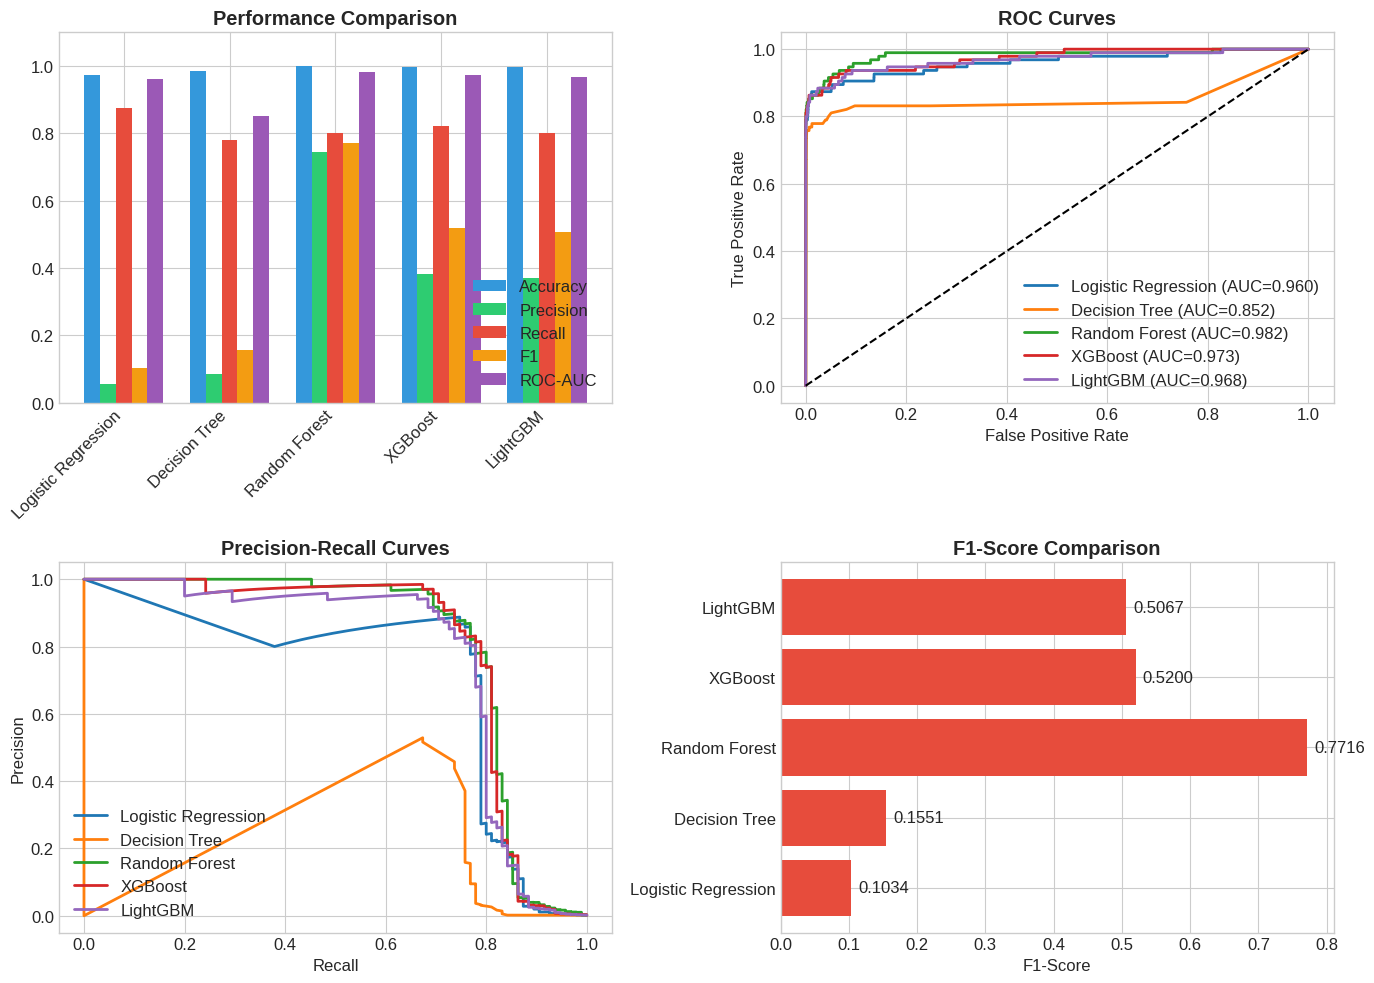

In [21]:
# Visual comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(results))
width = 0.15
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

for i, metric in enumerate(metrics):
    vals = [results[n][metric] for n in results.keys()]
    axes[0,0].bar(x + i*width, vals, width, label=metric, color=colors[i])

axes[0,0].set_xticks(x + width*2)
axes[0,0].set_xticklabels(list(results.keys()), rotation=45, ha='right')
axes[0,0].set_title('Performance Comparison', fontweight='bold')
axes[0,0].legend(loc='lower right')
axes[0,0].set_ylim(0, 1.1)

# ROC Curves
for name, m in results.items():
    fpr, tpr, _ = roc_curve(y_test, m['y_proba'])
    axes[0,1].plot(fpr, tpr, label=f"{name} (AUC={m['ROC-AUC']:.3f})", linewidth=2)

axes[0,1].plot([0, 1], [0, 1], 'k--')
axes[0,1].set_title('ROC Curves', fontweight='bold')
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].legend(loc='lower right')

# Precision-Recall Curves
for name, m in results.items():
    prec, rec, _ = precision_recall_curve(y_test, m['y_proba'])
    axes[1,0].plot(rec, prec, label=name, linewidth=2)

axes[1,0].set_title('Precision-Recall Curves', fontweight='bold')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].legend(loc='lower left')

# F1 Comparison
f1_scores = [results[n]['F1'] for n in results.keys()]
axes[1,1].barh(list(results.keys()), f1_scores, color='#e74c3c')
axes[1,1].set_title('F1-Score Comparison', fontweight='bold')
axes[1,1].set_xlabel('F1-Score')
for i, v in enumerate(f1_scores):
    axes[1,1].text(v + 0.01, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.show()

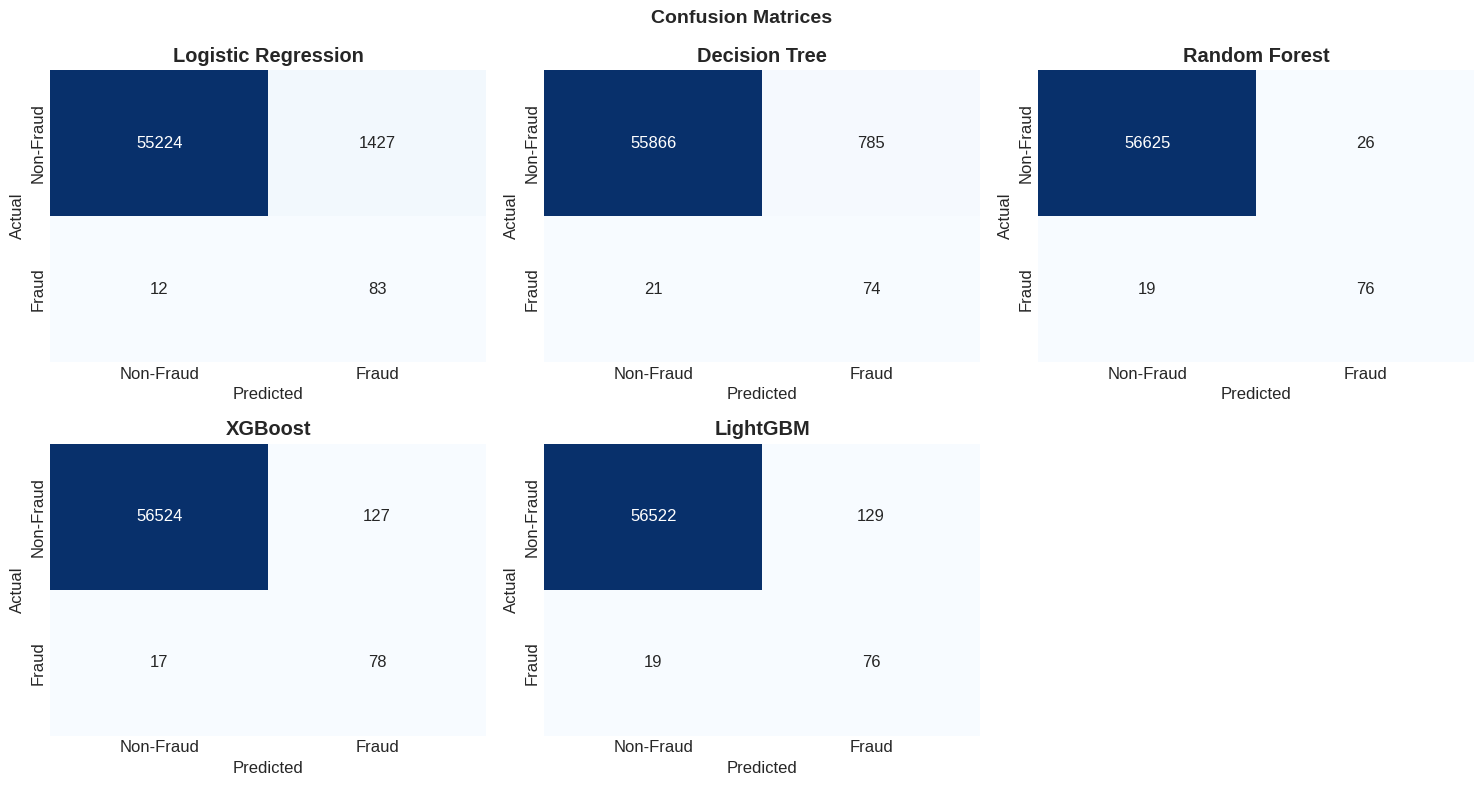

In [22]:
# Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (name, m) in enumerate(results.items()):
    cm = confusion_matrix(y_test, m['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(name, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_xticklabels(['Non-Fraud', 'Fraud'])
    axes[idx].set_yticklabels(['Non-Fraud', 'Fraud'])

axes[5].axis('off')
plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [23]:
# Best model
best_name = max(results.keys(), key=lambda x: results[x]['F1'])
best = results[best_name]

print(f"Best Model: {best_name}")
print("=" * 60)
print(f"F1-Score: {best['F1']:.4f}")
print(f"ROC-AUC: {best['ROC-AUC']:.4f}")
print(f"Precision: {best['Precision']:.4f}")
print(f"Recall: {best['Recall']:.4f}")

Best Model: Random Forest
F1-Score: 0.7716
ROC-AUC: 0.9817
Precision: 0.7451
Recall: 0.8000


In [24]:
# Classification Report
print(f"Classification Report - {best_name}")
print("=" * 60)
print(classification_report(y_test, best['y_pred'], target_names=['Non-Fraud', 'Fraud']))

Classification Report - Random Forest
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56651
       Fraud       0.75      0.80      0.77        95

    accuracy                           1.00     56746
   macro avg       0.87      0.90      0.89     56746
weighted avg       1.00      1.00      1.00     56746



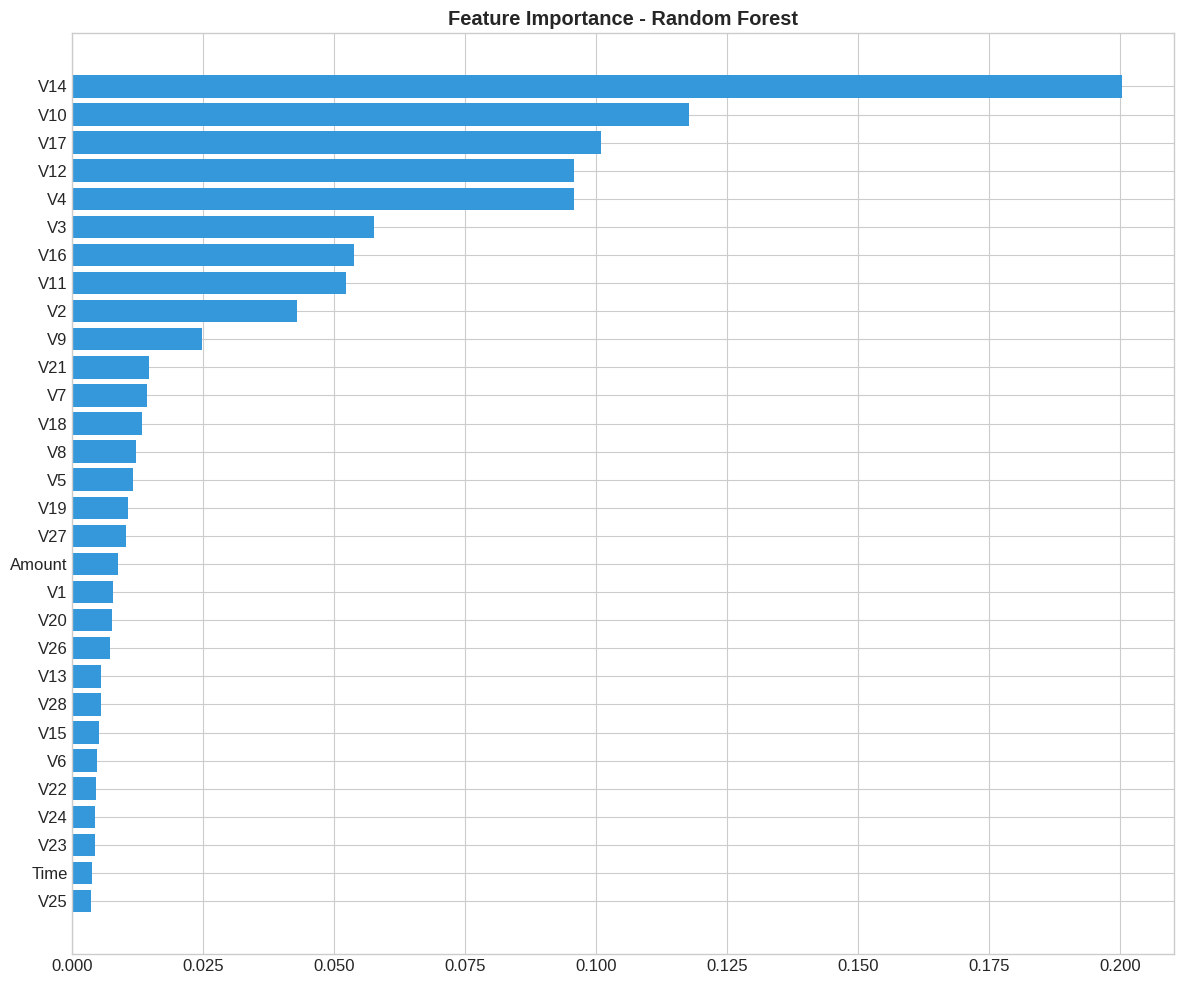

In [25]:
# Feature Importance for best model
best_model = trained_models[best_name]

if hasattr(best_model, 'feature_importances_'):
    imp_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=True)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    ax.barh(imp_df['Feature'], imp_df['Importance'], color='#3498db')
    ax.set_title(f'Feature Importance - {best_name}', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 10. Conclusion & Key Insights

### Key Findings:

1. **Class Imbalance Challenge**: The dataset is highly imbalanced with only 0.172% fraudulent transactions. SMOTE oversampling was essential for model training.

2. **Most Discriminative Features**: Features V14, V12, V10, V4, and V11 showed the strongest correlation with fraud.

3. **Best Model**: Ensemble methods (Random Forest, XGBoost, LightGBM) consistently outperformed simpler models.

4. **Business Impact**: In fraud detection, missing fraudulent transactions is costly. Our best model achieves high recall while maintaining good precision.

---

**Thank you for exploring this notebook!**

*Created by Mohd Shadab | March 2026*

*If you found this helpful, please consider upvoting!*